# 6주차 데이터 시퀀스 생성

In [5]:
import pandas as pd
import numpy as np

In [6]:
file_path = '../../tests/data_/returns.csv'
returns = pd.read_csv(file_path, index_col=0, parse_dates=True)

print(returns.shape)

(1826, 40)


In [7]:
sp500_tickers = [
    'NVDA',   # 엔비디아
    'AAPL',   # 애플
    'MSFT',   # 마이크로소프트
    'AMZN',   # 아마존
    'GOOGL',  # 알파벳 A
    'META',   # 메타 플랫폼스
    'BRK-B',  # 버크셔 해서웨이
    'LLY',    # 일라이 릴리
    'AVGO',   # 브로드컴
    'TSLA',   # 테슬라
    'WMT',    # 월마트
    'JPM',    # JP모건 체이스
    'UNH',    # 유나이티드헬스 그룹
    'XOM',    # 엑슨모빌
    'V',      # 비자
    'MA',     # 마스터카드
    'JNJ',    # 존슨앤드존슨
    'PG',     # 프록터 앤 갬블
    'ORCL',   # 오라클
    'HD',     # 홈디포
    'COST',   # 코스트코
    'ABBV',   # 애비비
    'BAC',    # 뱅크오브아메리카
    'NFLX',   # 넷플릭스
    'CVX',    # 쉐브론
    'AMD',    # AMD
    'KO',     # 코카콜라
    'CAT',    # 캐터필러
    'PLTR',   # 팔란티어
    'MU'      # 마이크론 테크놀로지
]

crypto_tickers = [
    'BTC-USD',   # 1. 비트코인 
    'ETH-USD',   # 2. 이더리움 
    'USDT-USD',  # 3. 테더 
    'BNB-USD',   # 4. 바이낸스 코인
    'XRP-USD',   # 5. 리플 
    'USDC-USD',  # 6. 유에스디 코인
    'SOL-USD',   # 7. 솔라나 
    'TRX-USD',   # 8. 트론
    'DOGE-USD',  # 9. 도지코인 
    'ADA-USD'    # 10. 카르다노
]


In [8]:
crypto_returns = returns[crypto_tickers]
stock_returns = returns[sp500_tickers]

crypto_medians = crypto_returns.median(axis=1)
stock_medians = stock_returns.median(axis=1)

targets_crypto = crypto_returns.apply(lambda x: (x >= crypto_medians).astype(int))
targets_stock = stock_returns.apply(lambda x: (x >= stock_medians).astype(int))

# 라벨링 끝난 정답지 다시 하나로 합치기 (나중에 모델에 넣기 위함)
targets = pd.concat([targets_stock, targets_crypto], axis=1)

In [9]:
import numpy as np
import pandas as pd

def create_rolling_sequences(crypto_ret, stock_ret, targets_df, seq_length, n_splits=3):
    # 3개의 독립된 모의고사 세트를 담을 '최상위 가방'
    splits_data = [] 
    
    total_length = len(crypto_ret)
    chunk_size = total_length // (n_splits + 3) 
    
    for i in range(n_splits):
        #매 Split마다 빈 상자를 새로 꺼냄
        X_train_list, y_train_list = [], []
        X_test_list, y_test_list = [], []
        
        # 1. 구간 인덱스 설정
        train_start = i * chunk_size
        train_end = train_start + (3 * chunk_size)
        test_end = train_end + chunk_size if i < n_splits - 1 else total_length
        
        # 2. Train 구간 자르기
        train_crypto = crypto_ret.iloc[train_start:train_end]
        train_stock = stock_ret.iloc[train_start:train_end]
        
        # 3. 평균/표준편차 구하기 (이번 회차만의 통계량)
        c_mean, c_std = train_crypto.mean(), train_crypto.std()
        s_mean, s_std = train_stock.mean(), train_stock.std()
        
        # 4. 정규화
        norm_crypto = (crypto_ret.iloc[train_start:test_end] - c_mean) / c_std
        norm_stock = (stock_ret.iloc[train_start:test_end] - s_mean) / s_std
        
        norm_all = pd.concat([norm_stock, norm_crypto], axis=1)
        target_chunk = targets_df.iloc[train_start:test_end]
        
        # 5. 슬라이딩 윈도우 생성
        for ticker in norm_all.columns:
            asset_X = norm_all[ticker].values
            asset_y = target_chunk[ticker].values
            
            for j in range(len(asset_X) - seq_length):
                window = asset_X[j : j + seq_length]
                target = asset_y[j + seq_length]
                
                # Train/Test 분할
                if (j + seq_length) < (train_end - train_start):
                    X_train_list.append(window)
                    y_train_list.append(target)
                else:
                    X_test_list.append(window)
                    y_test_list.append(target)
                    
        # 💡 해당 회차(Split)의 데이터만 3차원 배열로 변환
        X_train = np.expand_dims(np.array(X_train_list), -1)
        X_test = np.expand_dims(np.array(X_test_list), -1)
        y_train = np.array(y_train_list)
        y_test = np.array(y_test_list)
        
        # 💡 예쁘게 포장된 이번 회차 세트를 최상위 가방에 넣음
        splits_data.append((X_train, y_train, X_test, y_test))
        
    # 3개의 튜플(Train, Test 쌍)이 담긴 리스트 반환
    return splits_data


print("30일 시퀀스 롤링 데이터 생성")
# 결과물이 리스트 형태로 나옵니다.
splits_30 = create_rolling_sequences(crypto_returns, stock_returns, targets, 30)

print("\n✅ 데이터 생성 완료!")
for idx, (X_tr, y_tr, X_te, y_te) in enumerate(splits_30):
    print(f"\n[연구 세트 {idx + 1}회차]")
    print(f"▶ Train 셋: {X_tr.shape}, 정답지: {y_tr.shape}")
    print(f"▶ Test 셋: {X_te.shape}, 정답지: {y_te.shape}")

30일 시퀀스 롤링 데이터 생성

✅ 데이터 생성 완료!

[연구 세트 1회차]
▶ Train 셋: (35280, 30, 1), 정답지: (35280,)
▶ Test 셋: (12160, 30, 1), 정답지: (12160,)

[연구 세트 2회차]
▶ Train 셋: (35280, 30, 1), 정답지: (35280,)
▶ Test 셋: (12160, 30, 1), 정답지: (12160,)

[연구 세트 3회차]
▶ Train 셋: (35280, 30, 1), 정답지: (35280,)
▶ Test 셋: (12240, 30, 1), 정답지: (12240,)


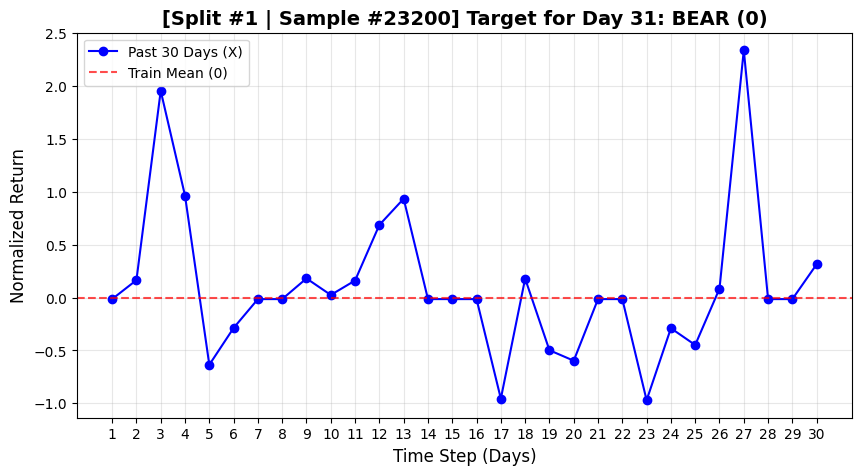

In [11]:
import matplotlib.pyplot as plt
import random
import numpy as np

# 1. 3개의 연구 세트 중 구경하고 싶은 세트 선택 (0: 1회차, 1: 2회차, 2: 3회차)
target_split = 0 

# 선택한 세트에서 Train 데이터와 정답지만 쏙 빼오기 (Test 데이터는 _ 로 무시)
X_train_split, y_train_split, _, _ = splits_30[target_split]

# 2. 선택된 Train 데이터 안에서 랜덤으로 문제 번호 하나 뽑기
random_idx = random.randint(0, len(X_train_split) - 1)

# 3. 해당 문제의 X(과거 30일 패턴)와 y(내일의 정답) 가져오기
sample_X = X_train_split[random_idx].flatten() 
sample_y = y_train_split[random_idx]

# 4. 정답 라벨(0 또는 1)을 사람이 읽기 쉽게 변환
target_text = "BULL (1)" if sample_y == 1 else "BEAR (0)"

# 5. 그래프 그리기
plt.figure(figsize=(10, 5))
plt.plot(range(1, 31), sample_X, marker='o', linestyle='-', color='b', label='Past 30 Days (X)')

# 0선 (평균선) 긋기: 해당 Split의 Train 평균선
plt.axhline(0, color='red', linestyle='--', alpha=0.7, label='Train Mean (0)')

# 그래프 꾸미기
plt.title(f"[Split #{target_split + 1} | Sample #{random_idx}] Target for Day 31: {target_text}", fontsize=14, fontweight='bold')
plt.xlabel("Time Step (Days)", fontsize=12)
plt.ylabel("Normalized Return", fontsize=12)
plt.xticks(range(1, 31)) # x축에 1~30일 표시
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()